In [1]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv(
    "../dataset/cleaned/clean_house_price_india.csv"
)

print("Dataset Loaded Successfully!")
print(df.shape)

df.head()

Dataset Loaded Successfully!
(13859, 24)


,id,date,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,...,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price,property_age
0,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,0,122005,52.9532,-114.321,3350,42847,3,76,838000,25
1,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,0,122006,52.9047,-114.485,2060,4500,1,51,805000,97
2,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,0,122007,52.9133,-114.590,2380,4750,1,67,790000,75
3,6762813157,42491,5,3.25,3660,11995,2.0,0,2,3,...,0,122008,52.7637,-114.050,3320,11241,3,72,785000,20
4,6762813599,42491,3,1.75,2240,10578,2.0,0,0,5,...,0,122006,52.9254,-114.482,1570,10578,3,71,750000,103


In [3]:
df["growth_score"] = (

    (df["grade_of_the_house"] /
     df["grade_of_the_house"].max()) * 30 +

    (df["number_of_schools_nearby"] /
     df["number_of_schools_nearby"].max()) * 20 +

    (df["living_area"] /
     df["living_area"].max()) * 25 +

    (1 -
     df["property_age"] /
     df["property_age"].max()) * 25

)

df["growth_score"] = df["growth_score"].round(2)

df[["growth_score"]].head()

,growth_score
0,73.60
1,41.48
2,47.98
3,78.26
4,52.05


In [4]:
def annual_growth(score):

    if score >= 80:
        return 0.08      # 8%

    elif score >= 60:
        return 0.06      # 6%

    elif score >= 40:
        return 0.05      # 5%

    else:
        return 0.03      # 3%


df["annual_growth_rate"] = (
    df["growth_score"]
    .apply(annual_growth)
)

df[
    ["growth_score",
     "annual_growth_rate"]
].head()

,growth_score,annual_growth_rate
0,73.60,0.06
1,41.48,0.05
2,47.98,0.05
3,78.26,0.06
4,52.05,0.05


In [5]:
df["price_after_1_year"] = (
    df["price"] *
    (1 + df["annual_growth_rate"])
).round(2)

df["price_after_3_years"] = (
    df["price"] *
    (1 + df["annual_growth_rate"]) ** 3
).round(2)

df["price_after_5_years"] = (
    df["price"] *
    (1 + df["annual_growth_rate"]) ** 5
).round(2)

df[
    [
        "price",
        "price_after_1_year",
        "price_after_3_years",
        "price_after_5_years"
    ]
].head()

,price,price_after_1_year,price_after_3_years,price_after_5_years
0,838000,888280.0,998071.41,1121433.03
1,805000,845250.0,931888.13,1027406.66
2,790000,829500.0,914523.75,1008262.43
3,785000,832100.0,934947.56,1050507.08
4,750000,787500.0,868218.75,957211.17


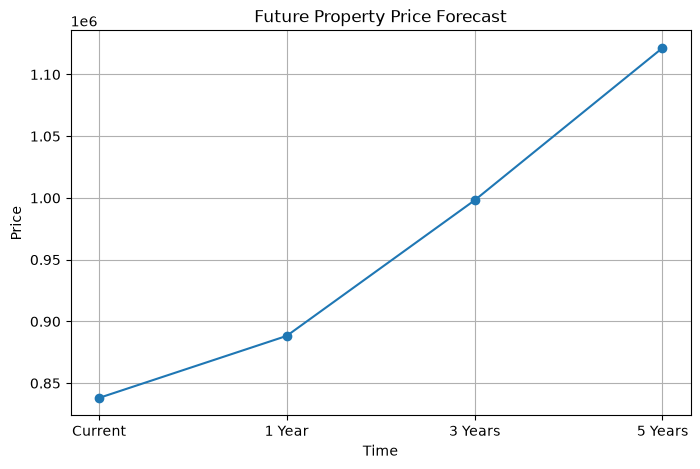

In [6]:
import matplotlib.pyplot as plt

sample = df.iloc[0]

years = [
    "Current",
    "1 Year",
    "3 Years",
    "5 Years"
]

prices = [
    sample["price"],
    sample["price_after_1_year"],
    sample["price_after_3_years"],
    sample["price_after_5_years"]
]

plt.figure(figsize=(8,5))

plt.plot(
    years,
    prices,
    marker="o"
)

plt.title(
    "Future Property Price Forecast"
)

plt.xlabel("Time")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [7]:
import os

os.makedirs(
    "../dataset/processed",
    exist_ok=True
)

df.to_csv(
    "../dataset/processed/future_price_forecast.csv",
    index=False
)

print("Future Price Forecast Dataset Saved Successfully!")

Future Price Forecast Dataset Saved Successfully!
